Second MODEL SUBMISSION — QUADRATIC DISCRIMINANT ANALYSIS (QDA)

Step 1 — Import Libraries

In [1]:
# Step 1: Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


Step 2 — Load Data

In [2]:
# Step 2: Load train, test, and sample_submission
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

train.head()


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


Step 3 — Inspect Data

In [3]:
# Step 3: Inspect structure
print(train.shape)
print(train.dtypes)
print(train.isnull().sum())

print(train["NObeyesdad"].value_counts())


(20758, 18)
id                                  int64
Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object
id                                0
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FA

Step 4 — Separate Features and Target

In [4]:
# Step 4: Separate X and y
target = "NObeyesdad"

X = train.drop(columns=[target])
y = train[target]

# Remove ID column if present
if "id" in X.columns:
    X = X.drop(columns=["id"])

# Prepare test set
test_ids = test["id"] if "id" in test.columns else None
X_test = test.drop(columns=["id"]) if "id" in test.columns else test


Step 5 — Identify Numeric and Categorical Columns

In [5]:
# Step 5: Identify column types
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numeric_features, categorical_features


(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'],
 ['Gender',
  'family_history_with_overweight',
  'FAVC',
  'CAEC',
  'SMOKE',
  'SCC',
  'CALC',
  'MTRANS'])

Step 6 — Build Preprocessing + QDA Pipeline

In [6]:
# Step 6: Preprocessing + QDA pipeline

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

qda_clf = QuadraticDiscriminantAnalysis()

qda_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", qda_clf)
])


Step 7 — Train/Validation Split + Fit QDA

In [7]:
# Step 7: Train/validation split
X_train_qda, X_valid_qda, y_train_qda, y_valid_qda = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

qda_pipeline.fit(X_train_qda, y_train_qda)


C:\Users\sjrey\anaconda3\Lib\site-packages\sklearn\discriminant_analysis.py:926: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender',
                                                   'family_history_with_overweight',
                                                   'FAVC', 'CAEC', 'SMOKE',
                                                   'SCC', 'CALC',
                                                   'MTRANS'])])),
                ('model', QuadraticDiscriminantAnalysis())])

Step 8 — Evaluate QDA

In [8]:
# Step 8: Evaluate QDA
y_pred_valid_qda = qda_pipeline.predict(X_valid_qda)

print("Validation Accuracy (QDA):", accuracy_score(y_valid_qda, y_pred_valid_qda))
print(classification_report(y_valid_qda, y_pred_valid_qda))
print(confusion_matrix(y_valid_qda, y_pred_valid_qda))


Validation Accuracy (QDA): 0.6832851637764933
                     precision    recall  f1-score   support

Insufficient_Weight       0.79      0.88      0.83       505
      Normal_Weight       0.68      0.63      0.65       617
     Obesity_Type_I       0.53      0.47      0.49       582
    Obesity_Type_II       0.59      0.97      0.73       650
   Obesity_Type_III       0.96      1.00      0.98       809
 Overweight_Level_I       0.71      0.19      0.30       485
Overweight_Level_II       0.44      0.40      0.42       504

           accuracy                           0.68      4152
          macro avg       0.67      0.65      0.63      4152
       weighted avg       0.69      0.68      0.66      4152

[[444  54   1   0   2   2   2]
 [113 387  20   3  17  23  54]
 [  1   2 271 250   5   8  45]
 [  0   1  12 633   0   1   3]
 [  0   0   1   1 806   0   1]
 [  3 102  95  33   9  94 149]
 [  0  24 116 157   1   4 202]]


Step 9 — Confusion Matrix Heatmap

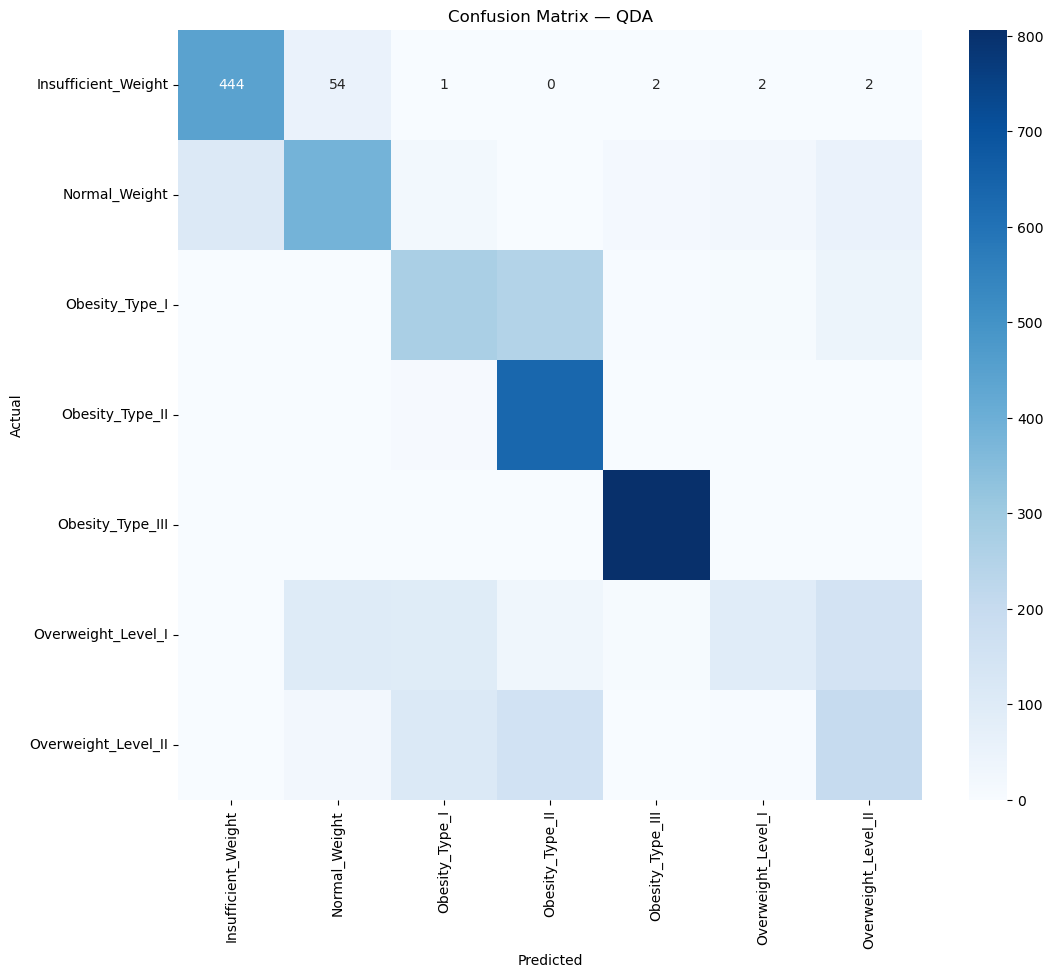

In [9]:
# Step 9: Confusion matrix heatmap
plt.figure(figsize=(12,10))
cm = confusion_matrix(y_valid_qda, y_pred_valid_qda)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=qda_pipeline.classes_,
            yticklabels=qda_pipeline.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — QDA")

plt.savefig("Obesity-Risk-ML-Classification/Model_2_Quadratic Discriminant Analysis (QDA)/reports/figures/confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()


Step 10 — Classification Report Heatmap

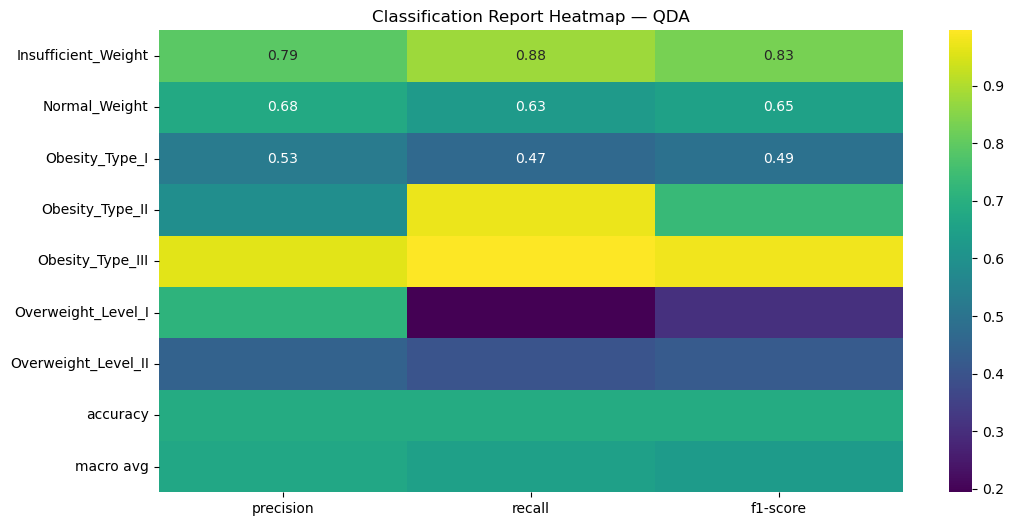

In [10]:
# Step 10: Classification report heatmap
report = classification_report(y_valid_qda, y_pred_valid_qda, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(12,6))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="viridis")
plt.title("Classification Report Heatmap — QDA")

plt.savefig("Obesity-Risk-ML-Classification/Model_2_Quadratic Discriminant Analysis (QDA)/reports/figures/classification_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()


Step 11 — QDA Class Means Visualization

In [11]:
# Step 11 — QDA Class Means Visualization

# Extract the actual feature names after preprocessing
feature_names = qda_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Build the DataFrame using the correct 30 column names
means_df = pd.DataFrame(
    qda_pipeline.named_steps["model"].means_,
    columns=feature_names,
    index=qda_pipeline.classes_
)


Step 12 — QDA Covariance Determinants (Class‑Specific)

In [12]:
# Step 12: Covariance determinant visualization
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# Add store_covariance=True here
qda_model = QuadraticDiscriminantAnalysis(store_covariance=True) 

# Example of how your pipeline setup might look:
# qda_pipeline = Pipeline([
#     ('preprocessor', preprocessor),
#     ('model', qda_model)
# ])


Step 13 — PCA Projection + QDA Decision Regions

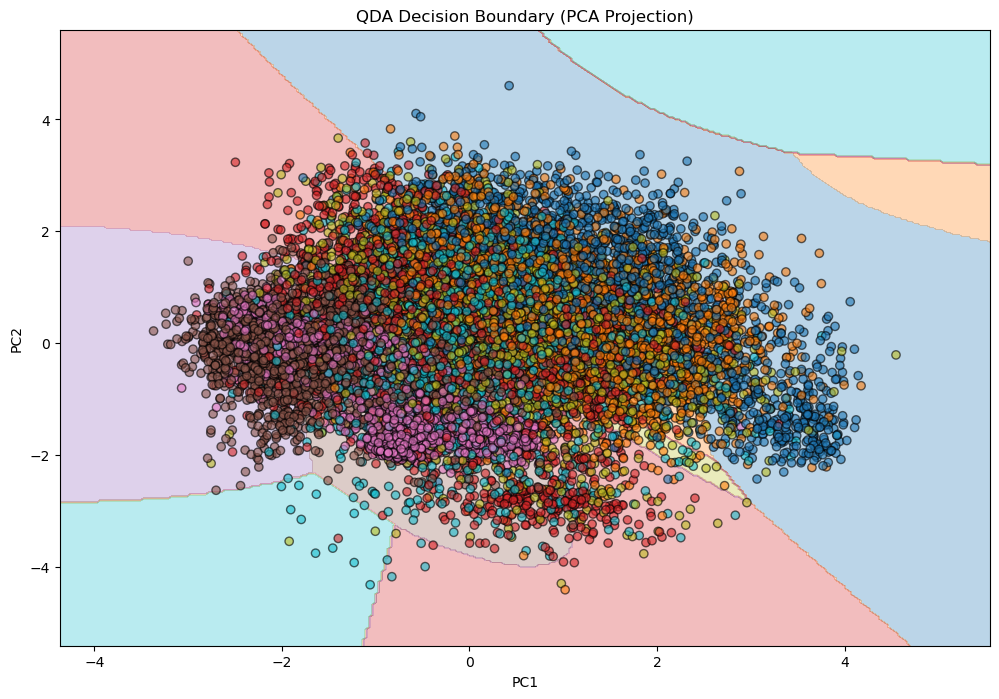

In [13]:
# Step 13: PCA projection + QDA decision regions
from sklearn.decomposition import PCA

# Transform training data
X_train_transformed = qda_pipeline.named_steps["preprocessor"].transform(X_train_qda)

# PCA to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_transformed)

# Fit QDA on PCA-reduced data for visualization only
qda_pca = QuadraticDiscriminantAnalysis()
qda_pca.fit(X_pca, y_train_qda)

# Mesh grid
x_min, x_max = X_pca[:,0].min() - 1, X_pca[:,0].max() + 1
y_min, y_max = X_pca[:,1].min() - 1, X_pca[:,1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Get the string text predictions
Z = qda_pca.predict(np.c_[xx.ravel(), yy.ravel()])

# Map the text classes to numerical indices
class_mapping = {label: idx for idx, label in enumerate(qda_pca.classes_)}

# Convert the text array into a numerical array
Z_num = np.array([class_mapping[val] for val in Z])

# Reshape the numerical array instead
Z = Z_num.reshape(xx.shape)


plt.figure(figsize=(12,8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="tab10")

plt.scatter(X_pca[:,0], X_pca[:,1],
            c=y_train_qda.map({c:i for i,c in enumerate(qda_pipeline.classes_)}),
            cmap="tab10", edgecolor="k", alpha=0.6)

plt.title("QDA Decision Boundary (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.savefig("Obesity-Risk-ML-Classification/Model_2_Quadratic Discriminant Analysis (QDA)/reports/figures/decision_boundary.png", dpi=300, bbox_inches="tight")

plt.show()


Step 14 — Retrain QDA on Full Training Data

In [14]:
# Step 14: Retrain on full dataset
qda_pipeline.fit(X, y)


C:\Users\sjrey\anaconda3\Lib\site-packages\sklearn\discriminant_analysis.py:926: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender',
                                                   'family_history_with_overweight',
                                                   'FAVC', 'CAEC', 'SMOKE',
                                                   'SCC', 'CALC',
                                                   'MTRANS'])])),
                ('model', QuadraticDiscriminantAnalysis())])

Step 15 Save trained QDA model

In [15]:
# Step 15 Save trained QDA model
import pickle

with open("qda_model.pkl", "wb") as file:
    pickle.dump(qda_pipeline, file)

print("QDA model saved as qda_model.pkl")

QDA model saved as qda_model.pkl


Step 16 — Predict on Test Set

In [16]:
# Step 16: Predict on Kaggle test data
test_preds_qda = qda_pipeline.predict(X_test)
test_preds_qda[:10]


array(['Obesity_Type_II', 'Obesity_Type_I', 'Obesity_Type_III',
       'Obesity_Type_I', 'Obesity_Type_III', 'Insufficient_Weight',
       'Insufficient_Weight', 'Normal_Weight', 'Normal_Weight',
       'Insufficient_Weight'], dtype=object)

Step 17 — Build Submission File

In [17]:
# Step 17: Build submission file
submission_qda = sample_submission.copy()
submission_qda["NObeyesdad"] = test_preds_qda

submission_qda.head()


,id,NObeyesdad
0,20758,Obesity_Type_II
1,20759,Obesity_Type_I
2,20760,Obesity_Type_III
3,20761,Obesity_Type_I
4,20762,Obesity_Type_III


Step 18 — Save CSV for Kaggle Submission #4

In [18]:
# Step 18: Save QDA submission
submission_qda.to_csv("submission_qda.csv", index=False)
